['datetime', 'price', 'hour']
¿Hay duplicados en el índice? False
Índices duplicados: DatetimeIndex([], dtype='datetime64[us]', name='datetime', freq=None)
Estadístico ADF: -6.4381
p-valor: 0.0000
La serie es estacionaria (p-valor <= 0.05)
Tamaño entrenamiento: 43824
Tamaño prueba: 24
                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                43824
Model:                 ARIMA(1, 0, 1)   Log Likelihood             -167796.500
Date:                Mon, 06 Apr 2026   AIC                         335600.999
Time:                        11:29:00   BIC                         335635.751
Sample:                    01-01-2020   HQIC                        335611.952
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---

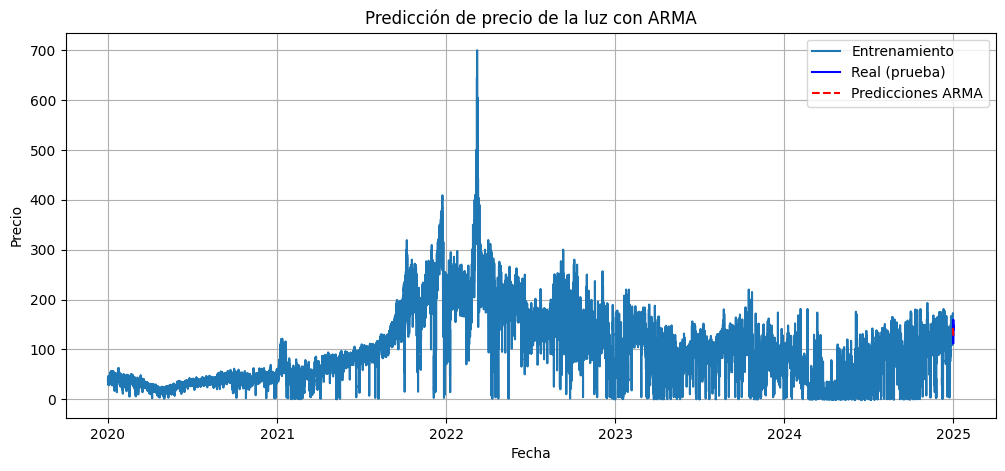

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

# ==============================
# 1. Cargar los datos
# ==============================
df = pd.read_csv('limpiezaPrecio5_Omie2020_2024.csv', sep=";")

# Ver las primeras filas
print(df.columns.tolist())
# ==============================
# 2. Preparar la serie temporal
# ==============================
# Convertir la columna de datetime a tipo datetime y ponerla como indice
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Ordenar por fecha por si acaso
df.sort_index(inplace=True)


# Seleccionamos la columna de precio (la que queremos predecir)
#serie = df['price']   # precio contiene valores nulos, cambio de hora agosto
serie = df['price'].replace([np.inf, -np.inf], np.nan).dropna() #quitamos valores erroneos

# Comprobar si hay fechas u horas repetidas
print("¿Hay duplicados en el índice?", serie.index.duplicated().any())

duplicados = serie.index[serie.index.duplicated(keep=False)].unique()
print("Índices duplicados:", duplicados[:10])  # muestra los primeros 10


# Asigna frecuencia, para nosostros H para una frecuencia en horas
serie = serie.asfreq('h')   # o 'D' para dias

# ==============================
# 3. Verificar estacionariedad (opcional pero recomendado)
# ==============================
# El modelo ARMA asume que la serie es estacionaria.
# Realizamos el test de Dickey-Fuller aumentado.
resultado = adfuller(serie)
print(f'Estadístico ADF: {resultado[0]:.4f}')
print(f'p-valor: {resultado[1]:.4f}')
if resultado[1] <= 0.05:
    print("La serie es estacionaria (p-valor <= 0.05)")
else:
    print("La serie NO es estacionaria. Se recomienda diferenciarla")
    # Diferenciamos una vez
    serie_diff = serie.diff().dropna()
    print("Se ha creado 'serie_diff' para continuar")
    # Vamos a trabajar con la serie diferenciada
    serie = serie_diff

# ==============================
# 4. Dividir en entrenamiento y prueba
# ==============================
# Por ejemplo, dejamos los últimos 24 puntos para prueba
train = serie[:-24]
test = serie[-24:]

print(f"Tamaño entrenamiento: {len(train)}")
print(f"Tamaño prueba: {len(test)}")

# ==============================
# 5. Elegir los órdenes p y q del modelo ARMA
# ==============================
# Para simplificar, probamos con p=1, q=1.
# Más adelante probar otros valores (ej. (2,0,1), etc.)
p = 1
q = 1
# En ARIMA, el orden es (p, d, q). Como usamos ARMA, d=0.
modelo = ARIMA(train, order=(p, 0, q))

# Ajustar el modelo
modelo_ajustado = modelo.fit()

# Mostrar un resumen del modelo
print(modelo_ajustado.summary())

# ==============================
# 6. Predecir los valores del conjunto de prueba
# ==============================
# forecast recibe el número de pasos a predecir
predicciones = modelo_ajustado.forecast(steps=len(test))
predicciones.index = test.index   # para que luego se pueda gaficar bien

# ==============================
# 7. Evaluar el modelo
# ==============================
# Calcular el error cuadrático medio (RMSE)
rmse = np.sqrt(mean_squared_error(test, predicciones))
print(f"RMSE en prueba: {rmse:.4f}")

# ==============================
# 8. Graficar resultados
# ==============================
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Entrenamiento')
plt.plot(test.index, test, label='Real (prueba)', color='blue')
plt.plot(test.index, predicciones, label='Predicciones ARMA', color='red', linestyle='--')
plt.title('Predicción de precio de la luz con ARMA')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)
plt.show()

### Explicacion codigo ARMA



## ARIMA(1,0,1) significa:

AR(1): Autoregresion, se usa el valor anterior de la serie (precio de hace un periodo) para predecir el actual.

I(0): Integracion, no se ha hecho diferenciación (porque los datos ya son estacionarios).

MA(1): Media Aritmetica, usa el error de predicción anterior para corregir la predicción actual.

No. Observations: 43824, cuantas mas mejor, da confianza en los resultados.

## Variables

coef: el valor estimado de cada parámetro.

const (92.64): el nivel base del precio cuando no hay influencia de los términos AR ni MA. Es importante porque da el valor medio.

ar.L1 (0.976): el efecto del precio anterior. Casi 1 significa que el precio de hoy es casi igual al de ayer más un pequeño ajuste. Muy importante porque captura la persistencia de la serie.

ma.L1 (0.383): el efecto del error de predicción anterior. Ayuda a corregir los errores pasados, mejorando la precisión.

sigma2 (124.11): la varianza de los errores del modelo. Indica cuánto se dispersan las predicciones. Mas alto peor

P>|z| = 0.000 para todos los coeficientes, son estadísticamente significativos (muy poco probable que su valor real sea cero, comprobar). Esto seria brutal.

Log Likelihood: -167827.246 Es la "verosimilitud" de los datos dado el modelo. Solo tiene sentido al comparar modelos (a mayor valor, mejor).



Métricas de calidad del modelo

AIC: 335662.492
BIC: 335697.244
HQIC: 335673.445

Son criterios para comparar modelos de series temporales. Cuanto más bajos, mejor. Solos no dicen si el modelo es bueno, pero el modelo que tenga menor AIC/BIC suele ser mejor.

 ## Diagnósticos de los residuos (errores)

 Estos tests te dicen si el modelo ha capturado toda la información o si quedan patrones sin explicar.

 Ljung-Box (L1) (Q): 188.11   Prob(Q): 0.00
 Ljung-Box: comprueba si los errores están correlacionados entre sí. La probabilidad 0.00 significa que sí hay autocorrelación residual (los errores no son independientes). Esto es malo: indica que el modelo podría mejorar añadiendo más términos AR, MA o estacionalidad.


 Jarque-Bera (JB): 267880.43   Prob(JB): 0.00
 Jarque-Bera: comprueba si los errores siguen una distribución normal. La probabilidad 0.00 indica que no son normales. Es común en series financieras, pero puede afectar a los intervalos de confianza.


 Heteroskedasticity (H): 8.16   Prob(H) (two-sided): 0.00
 Heteroscedasticidad: indica si la varianza de los errores cambia con el tiempo. Prob 0.00 → hay heteroscedasticidad (la volatilidad no es constante). Esto es típico en precios y puede requerir modelos como GARCH.

 Error de predicción

 RMSE en prueba: 17.4293

 RMSE: raíz del error cuadrático medio(R^2) en el conjunto de prueba. Mide, en las mismas unidades que el precio, cuánto se equivoca el modelo en promedio. Un valor de 17.43 significa que, típicamente, el modelo falla en unos 17.43 unidades de precio. Hay que comparar con la magnitud de los precios para saber si es aceptable, cuanto mas ceracno a 0 mejor


## ¿Qué es más importante y por qué?
Coeficientes (ar.L1, ma.L1, const): son el corazón del modelo. Te dicen cómo se comporta la serie.

Significancia (P>|z|): si un coeficiente no es significativo,  reconsiderar el modelo.

Diagnósticos de residuos (Ljung-Box, JB, Heteroskedasticity): indican si el modelo es adecuado. En este caso, todos los tests fallan, lo que sugiere que el modelo actual no captura toda la estructura de los datos. Hace falta incluir estacionalidad (SARIMA), más rezagos, o modelar la varianza (GARCH).

RMSE: te da una idea práctica del error de predicción.


Conclusión general
 modelo ARIMA(1,0,1) tiene coeficientes muy significativos, pero los residuos muestran autocorrelación, no normalidad y varianza cambiante. Esto implica que, aunque el modelo explica parte de la dinámica, no es óptimo para hacer predicciones confiables. Orobar:

Probar un SARIMA con estacionalidad (si datos tienen ciclos semanales, mensuales, etc.).

Añadir más rezagos AR o MA.

Considerar un modelo GARCH para la volatilidad.